<a href="https://colab.research.google.com/github/MHolmesURI/Capstone-DSP-577/blob/main/Capstone_Project_(Tuned).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("sephora_website_dataset.csv")
df.head()

,id,brand,category,name,size,rating,number_of_reviews,love,price,value_price,...,MarketingFlags,MarketingFlags_content,options,details,how_to_use,ingredients,online_only,exclusive,limited_edition,limited_time_offer
0,2218774,Acqua Di Parma,Fragrance,Blu Mediterraneo MINIATURE Set,5 x 0.16oz/5mL,4.0,4,3002,66.0,75.0,...,True,online only,no options,This enchanting set comes in a specially handc...,Suggested Usage:-Fragrance is intensified by t...,Arancia di Capri Eau de Toilette: Alcohol Dena...,1,0,0,0
1,2044816,Acqua Di Parma,Cologne,Colonia,0.7 oz/ 20 mL,4.5,76,2700,66.0,66.0,...,True,online only,- 0.7 oz/ 20 mL Spray - 1.7 oz/ 50 mL Eau d...,An elegant timeless scent filled with a fresh-...,no instructions,unknown,1,0,0,0
2,1417567,Acqua Di Parma,Perfume,Arancia di Capri,5 oz/ 148 mL,4.5,26,2600,180.0,180.0,...,True,online only,- 1oz/30mL Eau de Toilette - 2.5 oz/ 74 mL E...,Fragrance Family: Fresh Scent Type: Fresh Citr...,no instructions,Alcohol Denat.- Water- Fragrance- Limonene- Li...,1,0,0,0
3,1417617,Acqua Di Parma,Perfume,Mirto di Panarea,2.5 oz/ 74 mL,4.5,23,2900,120.0,120.0,...,True,online only,- 1 oz/ 30 mL Eau de Toilette Spray - 2.5 oz/...,Panarea near Sicily is an an island suspended ...,no instructions,unknown,1,0,0,0
4,2218766,Acqua Di Parma,Fragrance,Colonia Miniature Set,5 x 0.16oz/5mL,3.5,2,943,72.0,80.0,...,True,online only,no options,The Colonia Miniature Set comes in an iconic A...,Suggested Usage:-Fragrance is intensified by t...,Colonia: Alcohol Denat.- Water- Fragrance- Lim...,1,0,0,0


In [3]:
print(df.shape)
print(df.columns.tolist())
print(df.info())

(9168, 21)
['id', 'brand', 'category', 'name', 'size', 'rating', 'number_of_reviews', 'love', 'price', 'value_price', 'URL', 'MarketingFlags', 'MarketingFlags_content', 'options', 'details', 'how_to_use', 'ingredients', 'online_only', 'exclusive', 'limited_edition', 'limited_time_offer']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      9168 non-null   int64  
 1   brand                   9168 non-null   object 
 2   category                9168 non-null   object 
 3   name                    9168 non-null   object 
 4   size                    9168 non-null   object 
 5   rating                  9168 non-null   float64
 6   number_of_reviews       9168 non-null   int64  
 7   love                    9168 non-null   int64  
 8   price                   9168 non-null   float64
 9   value_price     

In [4]:
df.describe(include="all")

,id,brand,category,name,size,rating,number_of_reviews,love,price,value_price,...,MarketingFlags,MarketingFlags_content,options,details,how_to_use,ingredients,online_only,exclusive,limited_edition,limited_time_offer
count,9.168000e+03,9168,9168,9168,9168,9168.000000,9168.000000,9.168000e+03,9168.000000,9168.00000,...,9168,9168,9168,9168,9168,9168,9168.000000,9168.000000,9168.000000,9168.000000
unique,NaN,324,143,9106,1623,NaN,NaN,NaN,NaN,NaN,...,2,10,564,8839,6497,6962,NaN,NaN,NaN,NaN
top,NaN,SEPHORA COLLECTION,Perfume,Blush,no size,NaN,NaN,NaN,NaN,NaN,...,False,0,no options,no details,no instructions,unknown,NaN,NaN,NaN,NaN
freq,NaN,496,665,4,3161,NaN,NaN,NaN,NaN,NaN,...,4786,4786,8377,14,1573,1630,NaN,NaN,NaN,NaN
mean,1.962952e+06,NaN,NaN,NaN,NaN,3.990020,282.139180,1.627859e+04,50.063237,51.82359,...,NaN,NaN,NaN,NaN,NaN,NaN,0.234839,0.264725,0.091841,0.000327
std,3.859714e+05,NaN,NaN,NaN,NaN,1.007707,890.642028,4.260651e+04,47.164989,49.45902,...,NaN,NaN,NaN,NaN,NaN,NaN,0.423921,0.441211,0.288817,0.018087
min,5.000000e+01,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000e+00,2.000000,2.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,1.819453e+06,NaN,NaN,NaN,NaN,4.000000,10.000000,1.600000e+03,24.000000,25.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
50%,2.072354e+06,NaN,NaN,NaN,NaN,4.000000,46.000000,4.800000e+03,35.000000,35.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
75%,2.230591e+06,NaN,NaN,NaN,NaN,4.500000,210.000000,1.380000e+04,59.000000,60.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,0.000000


In [5]:
df.isnull().sum().sort_values(ascending=False)

,0
id,0
brand,0
category,0
name,0
size,0
rating,0
number_of_reviews,0
love,0
price,0
value_price,0


In [6]:
df = df[df["rating"] > 0].copy()

# Reduce brand noise: keep only top 20 brands
top_brands = df["brand"].value_counts().nlargest(20).index
df["brand_grouped"] = df["brand"].apply(lambda x: x if x in top_brands else "Other")

# Feature Engineering - Size related features
def extract_size_numeric(size_str):
    if isinstance(size_str, str):
        # Regex to find numbers that could be part of a size (e.g., '1 oz', '30 mL', '5x0.16oz/5mL')
        match = re.search(r'(\d+\.?\d*)\s*(?:oz|ml|g|fl\.\s*oz|count|x|mL|fl\soz)?', size_str, re.IGNORECASE)
        if match:
            return float(match.group(1))
    return np.nan

df["size_numeric"] = df["size"].apply(extract_size_numeric)

# Feature Engineering - Category simplification
category_mapping = {
    'Fragrance': 'Perfume',
    'Cologne': 'Perfume',
    'Perfume': 'Perfume',
    'Face': 'Face Skincare',
    'Moisturizers': 'Face Skincare',
    'Cleansers': 'Face Skincare',
    'Treatments': 'Face Skincare',
    'Eye Creams & Treatments': 'Face Skincare',
    'Face Masks': 'Face Skincare',
    'Sunscreen': 'Face Skincare',
    'BB & CC Cream': 'Face Skincare',
    'Self Tanner': 'Face Skincare',
    'Hair': 'Hair',
    'Shampoo': 'Hair',
    'Conditioner': 'Hair',
    'Hair Masks': 'Hair',
    'Hair Styling Products': 'Hair',
    'Hair Dryers': 'Hair Tools',
    'Hair Straighteners & Curling Irons': 'Hair Tools',
    'Hair Color': 'Hair',
    'Hair Primers': 'Hair',
    'Scalp & Hair Treatments': 'Hair',
    'Body': 'Body',
    'Body Moisturizers': 'Body',
    'Body Wash & Shower Gel': 'Body',
    'Body Sunscreen': 'Body',
    'Body Self Tanners': 'Body',
    'Body Care': 'Body',
    'Bath & Shower': 'Body',
    'Face Makeup': 'Face Makeup',
    'Foundation': 'Face Makeup',
    'Concealer': 'Face Makeup',
    'Blush': 'Face Makeup',
    'Bronzer': 'Face Makeup',
    'Highlighter': 'Face Makeup',
    'Setting Spray & Powder': 'Face Makeup',
    'Lip': 'Lip',
    'Lipstick': 'Lip',
    'Lip Gloss': 'Lip',
    'Lip Balm & Treatment': 'Lip',
    'Lip Stain': 'Lip',
    'Eye': 'Eye',
    'Mascara': 'Eye',
    'Eyeliner': 'Eye',
    'Eyeshadow': 'Eye',
    'Eyebrow': 'Eye',
    'Eyelash Curlers': 'Eye Tools',
    'Makeup': 'Face Makeup'
}

df["new_category"] = df["category"].map(category_mapping).fillna("Other")

# Word count features
df["details_word_count"] = df["details"].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
df["howtouse_word_count"] = df["how_to_use"].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)

# extra engineered features
df["price_per_size"] = df["price"] / (df["size_numeric"].fillna(0) + 1)
df["value_ratio"] = df["value_price"] / (df["price"] + 1)
df["discount_amount"] = df["value_price"] - df["price"]
df["discount_percent"] = (df["value_price"] - df["price"]) / (df["value_price"] + 1)

# optional: cap extreme values a bit
for col in ["price", "value_price", "size_numeric", "price_per_size"]:
    upper = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper, upper, df[col])


In [7]:
target = "rating"

# Final engineered features for tuned regression models
df["log_price"] = np.log1p(df["price"])
df["log_value_price"] = np.log1p(df["value_price"])
df["value_per_size"] = df["value_price"] / (df["size_numeric"] + 1)
df["price_to_description"] = df["price"] / (df["details_word_count"] + 1)

features_final = [
    "brand_grouped",
    "new_category",
    "log_price",
    "log_value_price",
    "online_only",
    "exclusive",
    "limited_edition",
    "limited_time_offer",
    "size_numeric",
    "details_word_count",
    "howtouse_word_count",
    "price_per_size",
    "value_ratio",
    "discount_amount",
    "discount_percent",
    "value_per_size",
    "price_to_description"
]

numeric_features = [
    "log_price",
    "log_value_price",
    "online_only",
    "exclusive",
    "limited_edition",
    "limited_time_offer",
    "size_numeric",
    "details_word_count",
    "howtouse_word_count",
    "price_per_size",
    "value_ratio",
    "discount_amount",
    "discount_percent",
    "value_per_size",
    "price_to_description"
]

categorical_features = ["brand_grouped", "new_category"]

X = df[features_final].copy()
y = df["rating"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

gb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
print(X.columns.tolist())
print(numeric_features)

['brand_grouped', 'new_category', 'log_price', 'log_value_price', 'online_only', 'exclusive', 'limited_edition', 'limited_time_offer', 'size_numeric', 'details_word_count', 'howtouse_word_count', 'price_per_size', 'value_ratio', 'discount_amount', 'discount_percent', 'value_per_size', 'price_to_description']
['log_price', 'log_value_price', 'online_only', 'exclusive', 'limited_edition', 'limited_time_offer', 'size_numeric', 'details_word_count', 'howtouse_word_count', 'price_per_size', 'value_ratio', 'discount_amount', 'discount_percent', 'value_per_size', 'price_to_description']


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "log_price",
    "log_value_price",
    "online_only",
    "exclusive",
    "limited_edition",
    "limited_time_offer",
    "size_numeric",
    "details_word_count",
    "howtouse_word_count",
    "price_per_size",
    "value_ratio",
    "discount_amount",
    "discount_percent",
    "value_per_size",
    "price_to_description"
]

categorical_features = ["brand_grouped", "new_category"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV score:", -rf_grid.best_score_)

Best RF params: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Best RF CV score: 0.5439706049479459


In [12]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5]
}

gb_grid = GridSearchCV(
    gb_pipe,
    gb_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best GB params:", gb_grid.best_params_)
print("Best GB CV score:", -gb_grid.best_score_)

Best GB params: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best GB CV score: 0.5459668383541646


In [13]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

best_rf = rf_grid.best_estimator_
best_gb = gb_grid.best_estimator_

rf_preds = best_rf.predict(X_test)
gb_preds = best_gb.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(name)
    print("RMSE:", round(rmse, 4))
    print("R2:", round(r2, 4))
    print()

evaluate_model("Tuned Random Forest", y_test, rf_preds)
evaluate_model("Tuned Gradient Boosting", y_test, gb_preds)

Tuned Random Forest
RMSE: 0.5293
R2: 0.0643

Tuned Gradient Boosting
RMSE: 0.5296
R2: 0.0632



In [14]:
best_model = best_rf  # or best_gb if it performs better

ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

importances = best_model.named_steps["model"].feature_importances_

final_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

final_importance_df.head(15)

,Feature,Importance
14,price_to_description,0.169874
7,details_word_count,0.129708
8,howtouse_word_count,0.125801
9,price_per_size,0.098057
13,value_per_size,0.069947
6,size_numeric,0.062117
10,value_ratio,0.061513
0,log_price,0.046369
1,log_value_price,0.045202
45,new_category_Perfume,0.030617


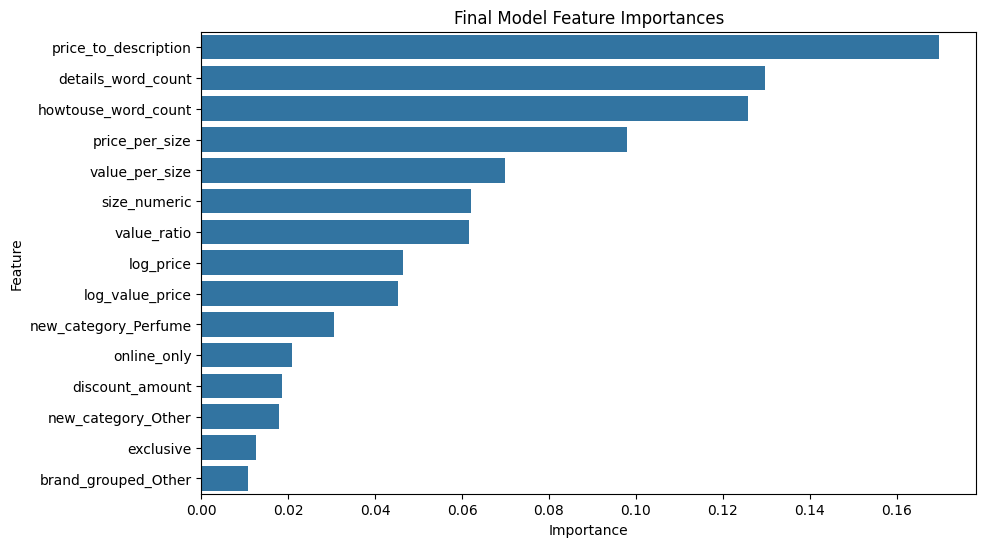

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=final_importance_df.head(15), x="Importance", y="Feature")
plt.title("Final Model Feature Importances")
plt.show()

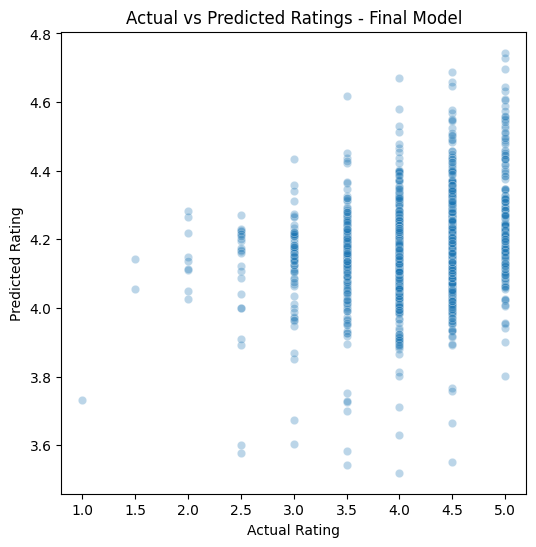

In [16]:
final_preds = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=final_preds, alpha=0.3)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings - Final Model")
plt.show()

In [17]:

df["high_rating"] = (df["rating"] >= 4.5).astype(int)

In [18]:
df["log_price"] = np.log1p(df["price"])
df["log_value_price"] = np.log1p(df["value_price"])

In [19]:
df["value_per_size"] = df["value_price"] / (df["size_numeric"] + 1)
df["price_to_description"] = df["price"] / (df["details_word_count"] + 1)

In [20]:
features_final = [
    "brand_grouped",
    "new_category",
    "log_price",
    "log_value_price",
    "online_only",
    "exclusive",
    "limited_edition",
    "limited_time_offer",
    "size_numeric",
    "details_word_count",
    "howtouse_word_count",
    "price_per_size",
    "value_ratio",
    "discount_amount",
    "discount_percent",
    "value_per_size",
    "price_to_description"
]

In [21]:
X = df[features_final].copy()
y = df["rating"].copy()

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
rf_grid.fit(X_train, y_train)
gb_grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['log_price',
                                                                          'log_value_price',
                                                                          'online_only',
                                                                          'exclusive',
                                                                          'limited_edition',
                                                                          'limited_time_offer',
                                                                          'size_numeric',
                                                                          'details_word_count',
                                                                          'howtouse_word_count',
                                                                          'price...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['brand_grouped',
                                                                          'new_category'])])),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.03, 0.05, 0.1],
                         'model__max_depth': [2, 3, 4],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [24]:
best_rf = rf_grid.best_estimator_
best_gb = gb_grid.best_estimator_

rf_preds = best_rf.predict(X_test)
gb_preds = best_gb.predict(X_test)

evaluate_model("Tuned Random Forest", y_test, rf_preds)
evaluate_model("Tuned Gradient Boosting", y_test, gb_preds)

Tuned Random Forest
RMSE: 0.5293
R2: 0.0643

Tuned Gradient Boosting
RMSE: 0.5296
R2: 0.0632



In [25]:
best_model = best_rf  # or best_gb

importances = best_model.named_steps["model"].feature_importances_

ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names = ohe.get_feature_names_out(["brand_grouped", "new_category"])

all_feature_names = numeric_features + list(encoded_cat_names)

final_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

final_importance_df.head(15)

,Feature,Importance
14,price_to_description,0.169874
7,details_word_count,0.129708
8,howtouse_word_count,0.125801
9,price_per_size,0.098057
13,value_per_size,0.069947
6,size_numeric,0.062117
10,value_ratio,0.061513
0,log_price,0.046369
1,log_value_price,0.045202
45,new_category_Perfume,0.030617


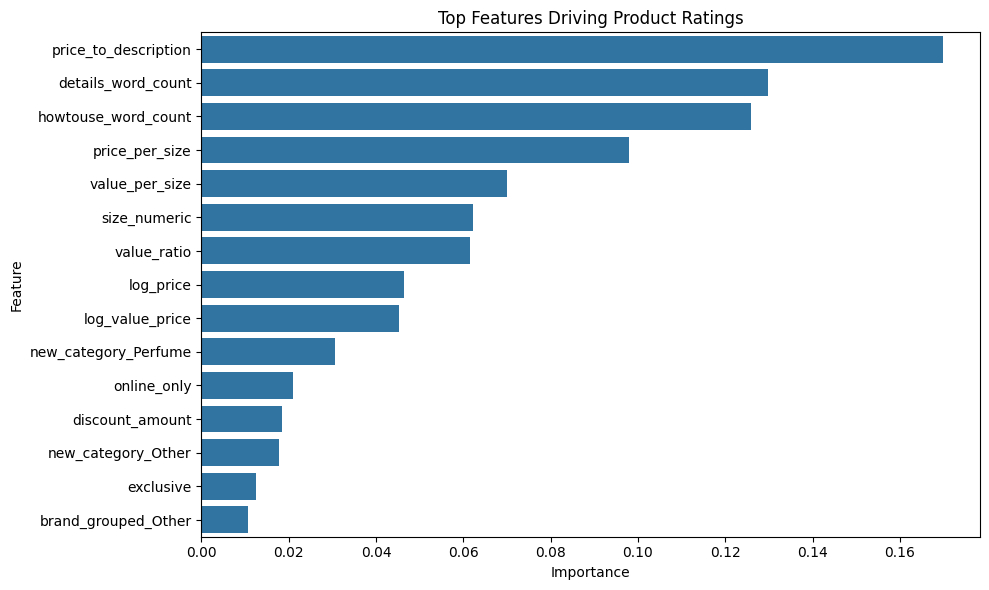

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Features Driving Product Ratings")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

<Axes: xlabel='Importance', ylabel='Feature'>

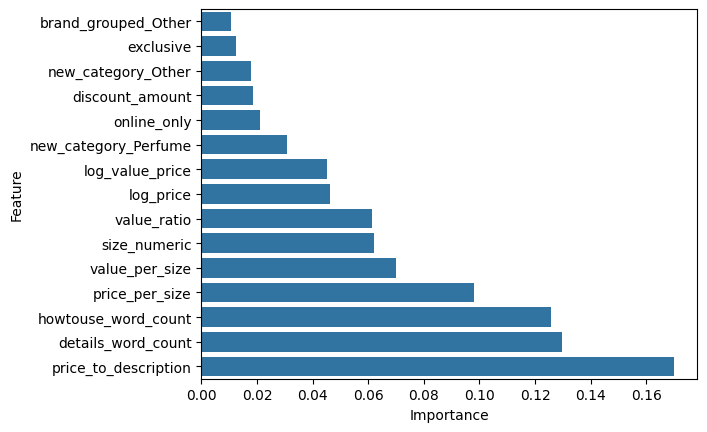

In [27]:
plot_df = final_importance_df.head(15).sort_values("Importance", ascending=True)

sns.barplot(data=plot_df, x="Importance", y="Feature")

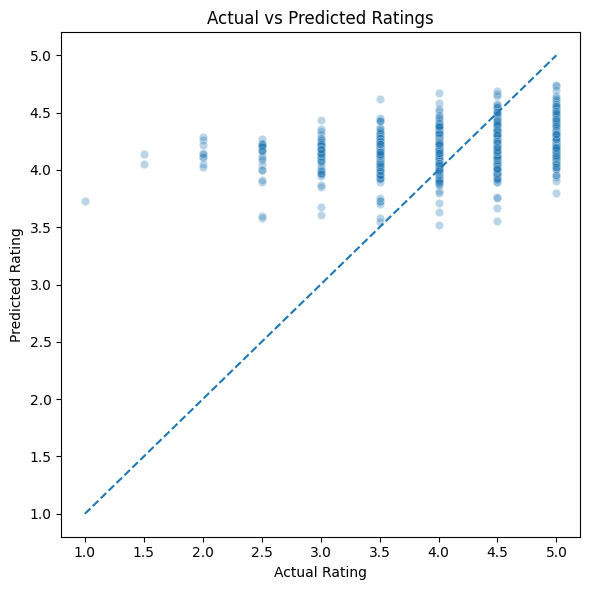

In [28]:
# Generate predictions again (just to be safe)
final_preds = best_model.predict(X_test)

plt.figure(figsize=(6, 6))

sns.scatterplot(
    x=y_test,
    y=final_preds,
    alpha=0.3
)

# Add ideal prediction line
min_val = min(y_test.min(), final_preds.min())
max_val = max(y_test.max(), final_preds.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")

plt.tight_layout()
plt.show()

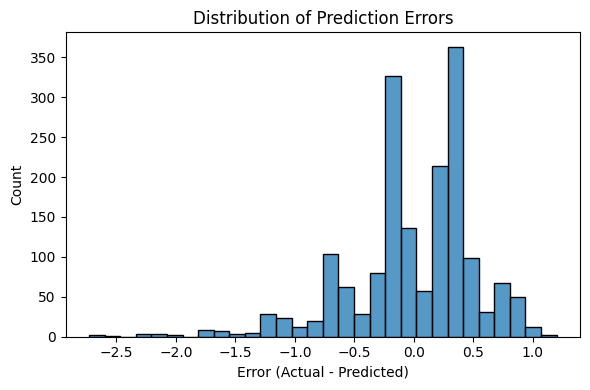

In [29]:
residuals = y_test - final_preds

plt.figure(figsize=(6, 4))

sns.histplot(residuals, bins=30)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

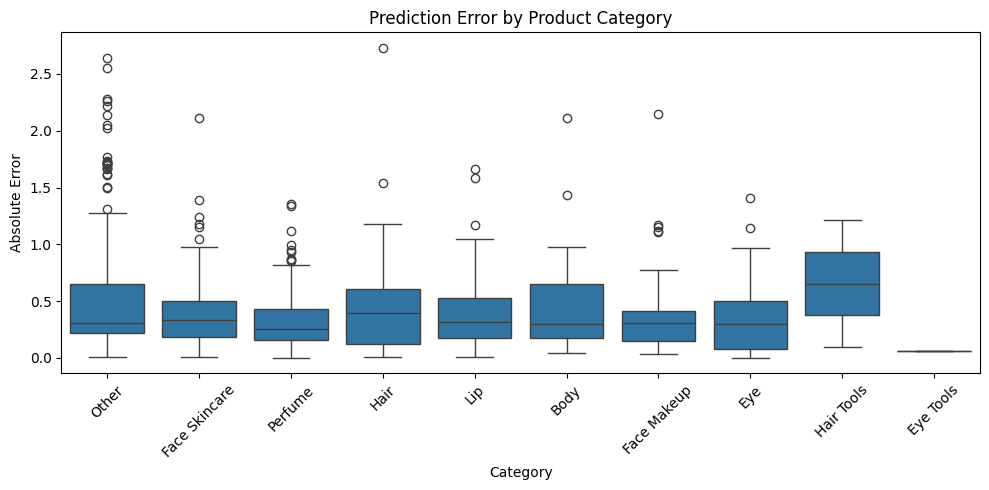

In [30]:
results_df = X_test.copy()
results_df["actual"] = y_test
results_df["predicted"] = final_preds
results_df["error"] = abs(results_df["actual"] - results_df["predicted"])

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=results_df,
    x="new_category",
    y="error"
)

plt.xticks(rotation=45)
plt.title("Prediction Error by Product Category")
plt.xlabel("Category")
plt.ylabel("Absolute Error")

plt.tight_layout()
plt.show()

In [31]:
df["high_rating"] = (df["rating"] >= 4.5).astype(int)

In [32]:
X = df[features_final].copy()
y_class = df["high_rating"].copy()

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

rf_clf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [35]:
rf_clf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_clf_grid = GridSearchCV(
    rf_clf_pipe,
    rf_clf_param_grid,
    cv=3,
    scoring="roc_auc",   # better for classification
    n_jobs=-1
)

rf_clf_grid.fit(X_train, y_train)

print("Best params:", rf_clf_grid.best_params_)
print("Best CV score (AUC):", rf_clf_grid.best_score_)

Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Best CV score (AUC): 0.6287073124806758


In [36]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

best_clf = rf_clf_grid.best_estimator_

y_pred = best_clf.predict(X_test)
y_prob = best_clf.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5832
ROC AUC: 0.6188

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.59      0.58       874
           1       0.59      0.58      0.58       880

    accuracy                           0.58      1754
   macro avg       0.58      0.58      0.58      1754
weighted avg       0.58      0.58      0.58      1754



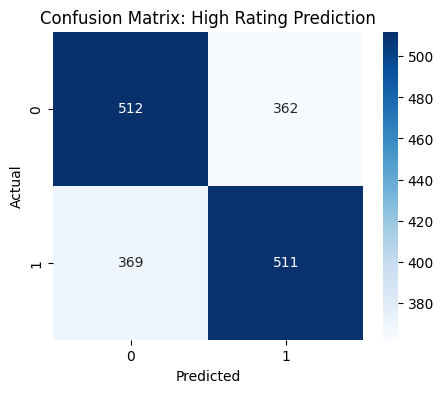

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: High Rating Prediction")

plt.show()

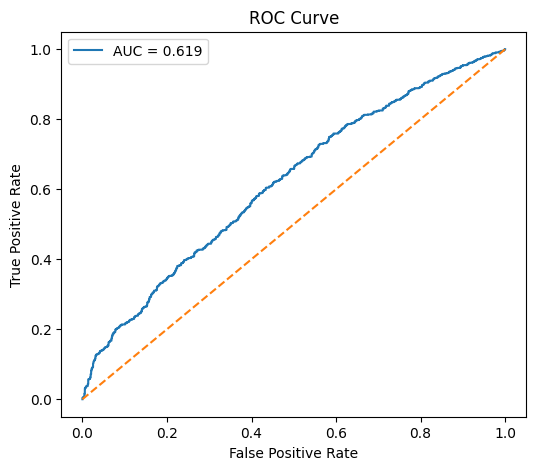

In [38]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [39]:
importances = best_clf.named_steps["model"].feature_importances_

ohe = best_clf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names = ohe.get_feature_names_out(["brand_grouped", "new_category"])

all_feature_names = numeric_features + list(encoded_cat_names)

importance_df_clf = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df_clf.head(15)

,Feature,Importance
14,price_to_description,0.111141
8,howtouse_word_count,0.100631
7,details_word_count,0.096747
9,price_per_size,0.090140
0,log_price,0.075789
10,value_ratio,0.075042
1,log_value_price,0.074502
6,size_numeric,0.072812
13,value_per_size,0.072168
44,new_category_Other,0.022644


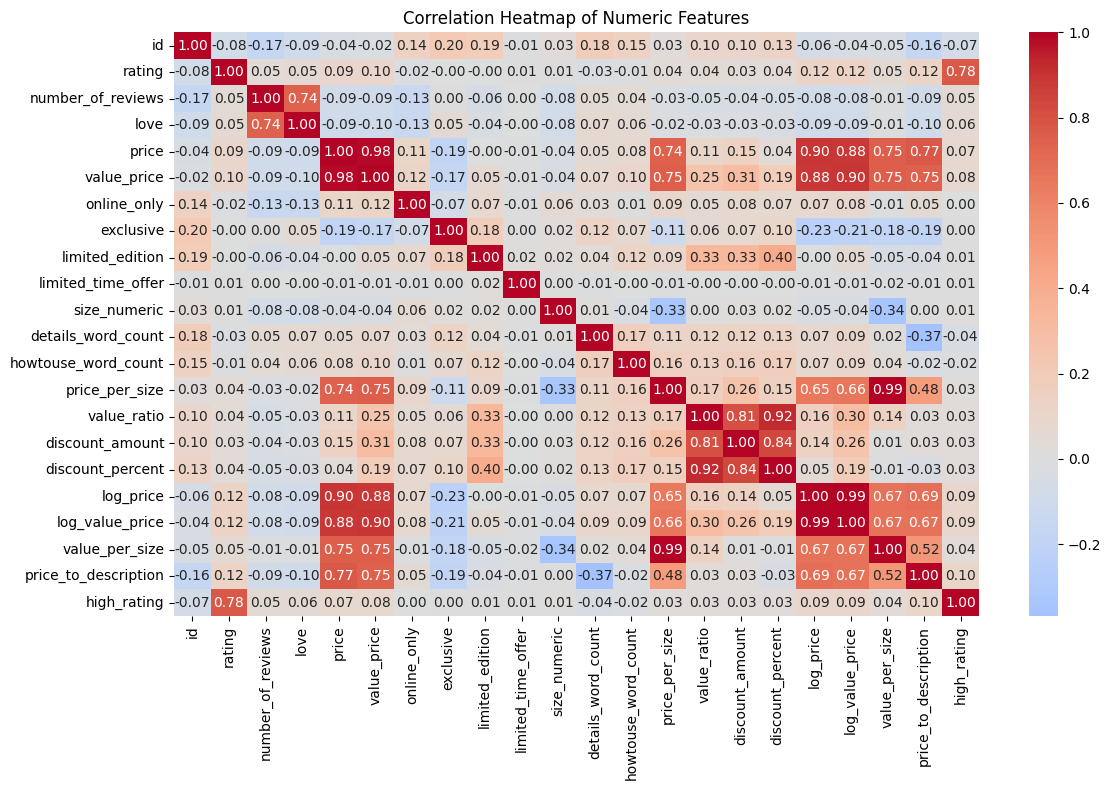

In [40]:
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

Linear Regression Results
------------------------------
RMSE: 0.5349
R^2: 0.0442


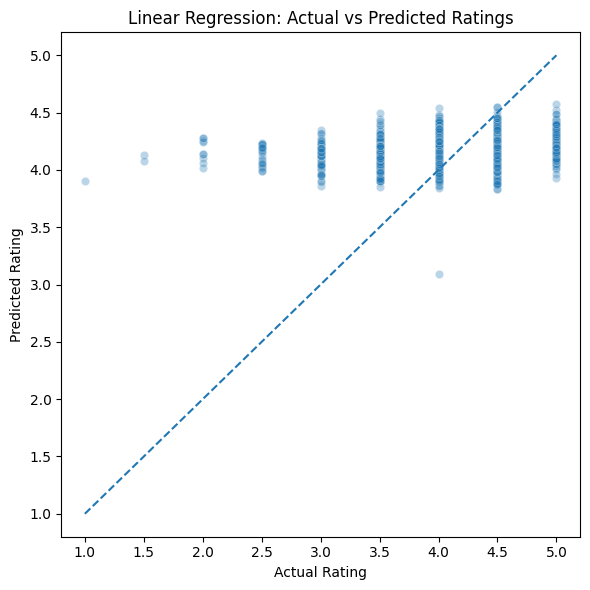

In [42]:
# LR all features
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use the original continuous target, not the binary high_rating variable
X = df[features_final].copy()
y = df["rating"].copy()

# Recreate train/test split for regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build linear regression pipeline
lr_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train the model
lr_pipe.fit(X_train, y_train)

# Make predictions
lr_preds = lr_pipe.predict(X_test)

# Evaluate the model
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Results")
print("------------------------------")
print("RMSE:", round(lr_rmse, 4))
print("R^2:", round(lr_r2, 4))

# Plot actual vs predicted ratings
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=lr_preds, alpha=0.3)

# Ideal prediction line
min_val = min(y_test.min(), lr_preds.min())
max_val = max(y_test.max(), lr_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Linear Regression: Actual vs Predicted Ratings")
plt.tight_layout()
plt.show()

Linear Regression (Ratings 4–5 Only)
-------------------------------------
RMSE: 0.3186
R^2: 0.058


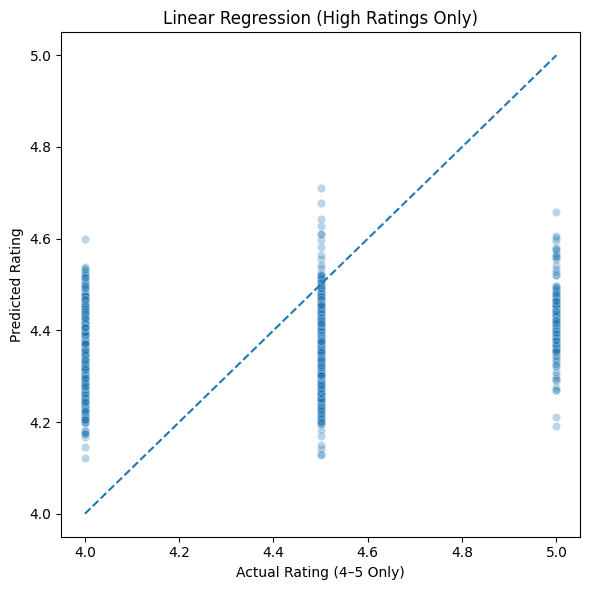

In [43]:
# 4-5 LR all features

# FILTER DATA: only keep ratings between 4 and 5
df_high = df[(df["rating"] >= 4) & (df["rating"] <= 5)].copy()

# Define features and target
X_high = df_high[features_final].copy()
y_high = df_high["rating"].copy()

# Train/test split
from sklearn.model_selection import train_test_split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_high, y_high, test_size=0.2, random_state=42
)

# Linear Regression pipeline
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

lr_high_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train model
lr_high_pipe.fit(X_train_h, y_train_h)

# Predictions
lr_high_preds = lr_high_pipe.predict(X_test_h)

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr_high_rmse = np.sqrt(mean_squared_error(y_test_h, lr_high_preds))
lr_high_r2 = r2_score(y_test_h, lr_high_preds)

print("Linear Regression (Ratings 4–5 Only)")
print("-------------------------------------")
print("RMSE:", round(lr_high_rmse, 4))
print("R^2:", round(lr_high_r2, 4))
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test_h, y=lr_high_preds, alpha=0.3)

# Ideal line
min_val = min(y_test_h.min(), lr_high_preds.min())
max_val = max(y_test_h.max(), lr_high_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Rating (4–5 Only)")
plt.ylabel("Predicted Rating")
plt.title("Linear Regression (High Ratings Only)")
plt.tight_layout()
plt.show()


Reduced Linear Regression Results
---------------------------------
RMSE: 0.534
R^2: 0.0476


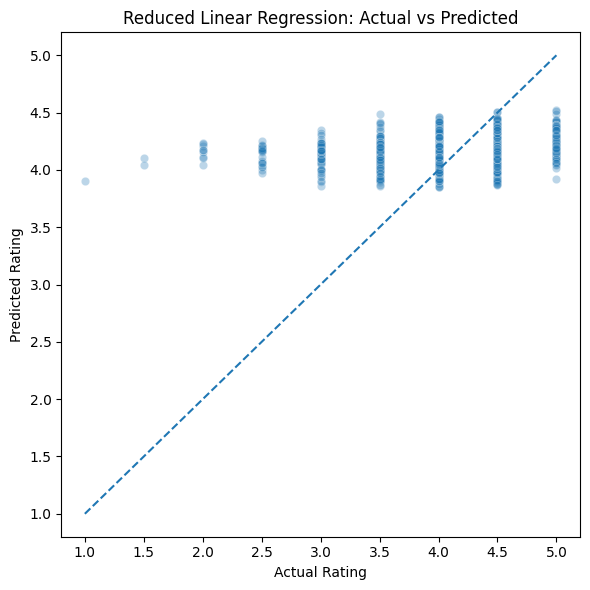

In [45]:
# REDUCED LINEAR REGRESSION MODEL
# This version rebuilds everything from scratch so the feature list,
# preprocessing steps, train/test split, model, and plot all match.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1. Define reduced feature set
# -----------------------------
features_reduced = [
    "brand_grouped",
    "new_category",
    "log_price",
    "size_numeric",
    "details_word_count",
    "howtouse_word_count",
    "price_per_size",
    "discount_percent",
    "price_to_description"
]

numeric_features_reduced = [
    "log_price",
    "size_numeric",
    "details_word_count",
    "howtouse_word_count",
    "price_per_size",
    "discount_percent",
    "price_to_description"
]

categorical_features_reduced = [
    "brand_grouped",
    "new_category"
]

# -----------------------------
# 2. Build X and y
# -----------------------------
X = df[features_reduced].copy()
y = df["rating"].copy()

# -----------------------------
# 3. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 4. Preprocessing pipelines
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_reduced),
        ("cat", categorical_transformer, categorical_features_reduced)
    ]
)

# -----------------------------
# 5. Linear regression pipeline
# -----------------------------
lr_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# -----------------------------
# 6. Train the model
# -----------------------------
lr_pipe.fit(X_train, y_train)

# -----------------------------
# 7. Make predictions
# -----------------------------
lr_preds = lr_pipe.predict(X_test)

# -----------------------------
# 8. Evaluate the model
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
r2 = r2_score(y_test, lr_preds)

print("Reduced Linear Regression Results")
print("---------------------------------")
print("RMSE:", round(rmse, 4))
print("R^2:", round(r2, 4))

# -----------------------------
# 9. Plot actual vs predicted
# -----------------------------
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=lr_preds, alpha=0.3)

min_val = min(y_test.min(), lr_preds.min())
max_val = max(y_test.max(), lr_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Reduced Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

Classification Results (High Rating ≥ 4.5)
------------------------------------------
Accuracy: 0.581

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.61      0.59       874
           1       0.59      0.55      0.57       880

    accuracy                           0.58      1754
   macro avg       0.58      0.58      0.58      1754
weighted avg       0.58      0.58      0.58      1754



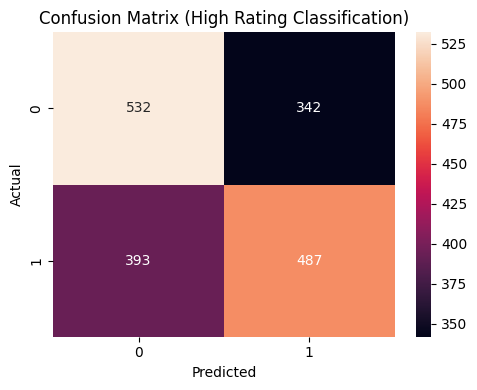

In [46]:
# -----------------------------
# 1. Create binary target
# -----------------------------
df["high_rating"] = (df["rating"] >= 4.5).astype(int)

# -----------------------------
# 2. Define features and target
# -----------------------------
features = [
    "brand_grouped",
    "new_category",
    "log_price",
    "size_numeric",
    "details_word_count",
    "howtouse_word_count",
    "price_per_size",
    "discount_percent",
    "price_to_description"
]

X = df[features].copy()
y = df["high_rating"]

# -----------------------------
# 3. Train/test split
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 4. Preprocessing
# -----------------------------
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "log_price",
    "size_numeric",
    "details_word_count",
    "howtouse_word_count",
    "price_per_size",
    "discount_percent",
    "price_to_description"
]

categorical_features = [
    "brand_grouped",
    "new_category"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# -----------------------------
# 5. Random Forest Classifier
# -----------------------------
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight="balanced"   # helps with imbalance
    ))
])

# Train model
rf_clf.fit(X_train, y_train)

# -----------------------------
# 6. Predictions
# -----------------------------
y_pred = rf_clf.predict(X_test)

# -----------------------------
# 7. Evaluation
# -----------------------------
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Classification Results (High Rating ≥ 4.5)")
print("------------------------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 8. Confusion Matrix Plot
# -----------------------------
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (High Rating Classification)")

plt.tight_layout()
plt.show()